<a href="https://colab.research.google.com/github/Muqtarali/Machine-Learning/blob/main/simple_end_to_end_ml_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/placement.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


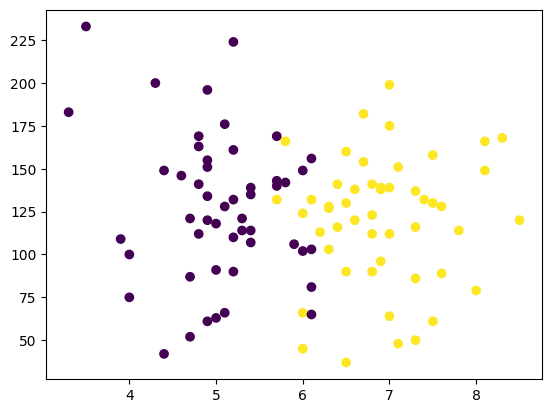

In [ ]:
#EDA

plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
# 1. Extract input and output cols
x=df.iloc[:,0:2]
y=df.iloc[:,-1]


In [ ]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y


NameError: name 'y' is not defined

In [ ]:
# 3. Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,_y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
x_train

,cgpa,iq
1,5.9,106.0
74,6.7,154.0
19,5.2,132.0
66,6.9,96.0
25,5.0,91.0
...,...,...
42,7.6,89.0
75,4.8,169.0
45,6.0,66.0
26,7.0,199.0


In [ ]:
_y_test

,placement
33,0
17,0
81,0
55,1
60,1
90,1
5,1
35,1
72,1
15,0


In [ ]:
# 2. Scale the values
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
#model train
from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression()

# Fit the model (Notice the capital 'X' in X_train)
model.fit(x_train, y_train)

LogisticRegression()

In [ ]:
modle.fit(x_train,y_train)

LogisticRegression()

In [ ]:
#pridect kar wa rha ha ham
model.predict(x_test)
y_predect=model.predict(x_test)


In [ ]:
# find the accuracy
from sklearn.metrics import accuracy_score
accuracy_score(_y_test,y_predect)

0.9

<Axes: >

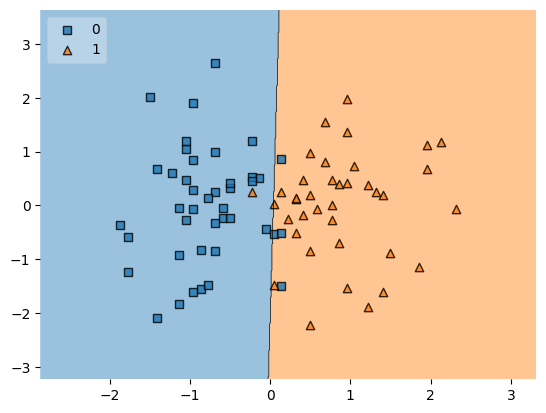

In [ ]:
#plot jo model ka patter dekhn ha data per \
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x_train, y_train.values, clf=modle, legend=2)

In [ ]:
# 6. Deploy the model
import pickle
pickle.dump(model,open('model.pkl','wb'))